# FraudGuard - Transaction Fraud Intelligence
## Notebook 3 - Predictive Modelling

### PACE: Construct - PD Model  

**Objective:** Build a fraud detection model using XGBoost with SMOTE resampling to handle class imbalance.  

**Key factors compared to credit risk modelling:**
- Extreme Imbalance (3.5% fraud vs 20.5% default)
- Time-based split - train on past, run on future
- Precision-Recall evaluation - not ROC or Gini
- Cost-sensitive threshold tuning  

**Input:** fraud_clean.csv(590,540 transactions, 60 features)  
**Output:** Fraud probability score per transaction

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from xgboost import XGBClassifier
from sklearn.metrics import(
    roc_auc_score, precision_recall_curve, 
    average_precision_score, classification_report,
    confusion_matrix
)
import shap
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
df = pd.read_csv('../data/fraud_clean.csv')
print(f"Shape: {df.shape}")
print(f"Fraud Rate: {df['isFraud'].mean()*100:.3f}%" )
print(f"Missing Values: {df.isnull().sum().sum()}")

Shape: (590540, 61)
Fraud Rate: 3.499%
Missing Values: 0


### Step 1 - Time-Based Train/Test Split  
Training on earlier transactions, testing on later ones.   
Simulates real deployment - model always predict future fraud.  
Split: First 80% by time  - to train, and last 20% - to test.

In [13]:
# Sort by time to ensure chronological split
df = df.sort_values('tx_day_elapsed').reset_index(drop = True)

# Define features and target
features_cols = [c for c in df.columns if c != 'isFraud']
target_col = 'isFraud'

X = df[features_cols]
y = df[target_col]

# Time-based split - 80/20% chronologically
split_idx = int(len(df)*0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Training set:          {X_train.shape[0]:,} transactions")
print(f"Test set:              {X_test.shape[0]:,} transactions")
print(f"\nFraud rate - Train:  {y_train.mean()*100:.3f}%")
print(f"Fraud rate - Test:     {y_test.mean()*100:.3f}%")

# Time span check
print(f"\nTrain time span: day "
      f"{df.iloc[:split_idx]['tx_day_elapsed'].min()} "
      f" to {df.iloc[:split_idx]['tx_day_elapsed'].max()}")
print(f"Test time span: day "
      f"{df.iloc[split_idx:]['tx_day_elapsed'].min()} "
      f" to {df.iloc[split_idx:]['tx_day_elapsed'].max()}")

Training set:          472,432 transactions
Test set:              118,108 transactions

Fraud rate - Train:  3.516%
Fraud rate - Test:     3.432%

Train time span: day 1  to 141
Test time span: day 141  to 182


### Step 2 - SMOTE Resampling  
Fraud rate: 3.5% - 28:1 class imbalance.  
SMOTE (Synthetic Minority Oversampling Technique) generates synthetic fraud examples in the training set.  
Applied to TRAINING data only - never to the test data.  
Test set must reflect real-world distribution.

In [18]:
# Install (if needed): pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
print(f"Before SMOTE:")
print(f" Training Fraud:    {y_train.sum():,}({y_train.mean()*100:.2f}%)")
print(f" Training Legit:    {(y_train==0).sum():,}")
print(f" Ratio:             {(y_train==0).sum()//y_train.sum()}:1")

# Apply SMOTE
smote = SMOTE(sampling_strategy = 0.1, #Fraud becomes 10% of training
              random_state = 42,
              k_neighbors = 5)
X_train_sm, y_train_sm = smote.fit_resample(X_train,y_train)

print(f"\nAfter SMOTE:")
print(f" Training Fraud:     {y_train_sm.sum():,}({y_train_sm.mean()*100:.2f}%)")
print(f" Training Legit:     {(y_train_sm==0).sum():,}")
print(f" Total Training:     {len(X_train_sm):,}")
print(f"\nTest set unchanged:{len(X_test):,} transactions")
print(f"Test fraud rate:     {y_test.mean()*100:.3f}%")

Before SMOTE:
 Training Fraud:    16,610(3.52%)
 Training Legit:    455,822
 Ratio:             27:1

After SMOTE:
 Training Fraud:     45,582(9.09%)
 Training Legit:     455,822
 Total Training:     501,404

Test set unchanged:118,108 transactions
Test fraud rate:     3.432%


### Step 3 - XGBoost Fraud Detection Model  
Transaction on SMOTE-resampled data.  
*scale_pos_weight* not needed - SMOTE handles imbalance.  
Parameters tuned for fraud detection context.

In [19]:
print("Training XGBoost Fraud Detection Model...")

model = XGBClassifier(n_estimators = 300, max_depth = 6,
                      learning_rate = 0.05, subsample = 0.8, 
                      colsample_bytree = 0.8, reg_alpha = 0.1,
                      red_lambda = 1.0, random_state = 42,
                      eval_metric = 'aucpr', verbosity = 0)
model.fit(
    X_train_sm, y_train_sm, eval_set = [(X_test, y_test)], verbose = False)

print("Model Trained Successfully")
print(f"Training Samples: {len(X_train_sm):,}")
print(f"Features:         {X_train_sm.shape[1]}")

Training XGBoost Fraud Detection Model...
Model Trained Successfully
Training Samples: 501,404
Features:         60


### Step 4 - Model Evaluation  
Primary metrics: precision, Recall, Average Precision  
Secondary metrics: ROC-AUC (for comparison only)

Business interpretation:  
- Precision of flagged transactions - *How many real fraud?*  
- Recall of all real frauds - *How many did we catch?*  
- Average precision: Overall model quality on fraud class

In [21]:
# Generate fraud probabilities on the test set
y_pred_proba = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

# Core metrics
auc_roc = roc_auc_score(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test,y_pred_proba)

print("Model Performance:")
print("="*40)
print(f"ROC-AUC:                 {auc_roc:.4f}")
print(f"Average Precision:       {avg_precision:.4f}")
print(f"\nClassification Report (default threshold 0.5):")
print(classification_report(y_test,y_pred,target_names=['Legitimate','Fraud']))

# Confusion metrrix
cm = confusion_matrix(y_test,y_pred)
print(f"Confusion matrix:")
print(f"                      Predicted Legit        Predicted Fraud")
print(f"Actual Legit          {cm[0][0]:>15,}        {cm[0][1]:>15,}")
print(f"Actual Fraud          {cm[1][0]:>15,}        {cm[1][1]:>15,}")

# Business Metrics
tn,fp,fn,tp = cm.ravel()
print(f"\nBusiness Metrics:")
print(f"   True Positives(fraud caught):       {tp:,}")
print(f"   False Positives(legit blocked):     {fp:,}")
print(f"   False Negatives(fraud missed):      {fn:,}")
print(f"   True Negatives(legit approved):     {tn:,}")
print(f"\nFraud-Friction Ratio: {tp/fp:.1f}:1" if fp>0 else "Perfect Precision")

Model Performance:
ROC-AUC:                 0.8958
Average Precision:       0.4976

Classification Report (default threshold 0.5):
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99    114055
       Fraud       0.74      0.35      0.47      4053

    accuracy                           0.97    118108
   macro avg       0.86      0.67      0.73    118108
weighted avg       0.97      0.97      0.97    118108

Confusion matrix:
                      Predicted Legit        Predicted Fraud
Actual Legit                  113,562                    493
Actual Fraud                    2,647                  1,406

Business Metrics:
   True Positives(fraud caught):       1,406
   False Positives(legit blocked):     493
   False Negatives(fraud missed):      2,647
   True Negatives(legit approved):     113,562

Fraud-Friction Ratio: 2.9:1


### Step 5 - Precision-Recall Curve and Threshold Tuning  
Default threshold(0.5) optimises for balanced classes. Fraud detection requires a lower threshold - catching more fraud at acceptable false positive cost.  
Optimal threshold selected using F-beta score (beta = 2) which weights recall twice as heavily as precision.

Optimal threshold: 0.1430
At this threshold:
 Precision: 0.3565 (35.7%)
 Recall:    0.5956 (59.6%)

Business Metrics at Optimal Threshold:
----------------------------------------
   Fraud caught:     2,414 (59.6% of all fraud)
   Fraud missed:     1,639
   Legit blocked:    4,357 (3.82% of legit)
   Fraud-Friction:   0.6:1


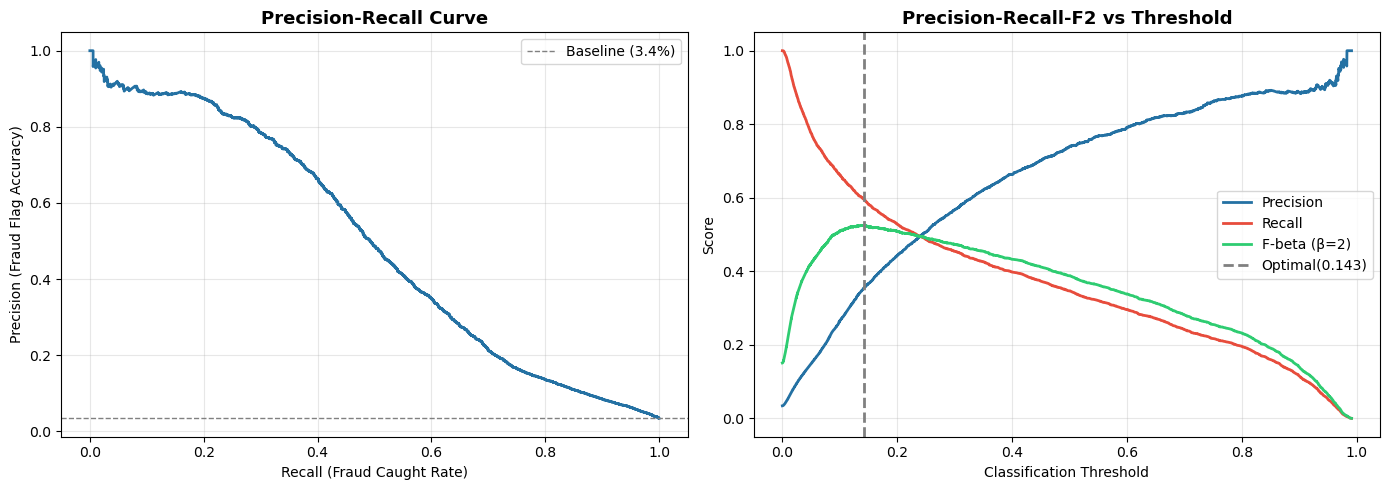

In [24]:
# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot PR curve
fig,axes = plt.subplots(1,2,figsize = (14,5))
axes[0].plot(recall,precision,color='#2471a3', linewidth = 2)
axes[0].axhline(y=y_test.mean(), color = 'gray', linestyle = '--', linewidth = 1,
                label = f'Baseline ({y_test.mean()*100:.1f}%)')
axes[0].set_title('Precision-Recall Curve',fontsize = 13, fontweight = 'bold')
axes[0].set_ylabel('Precision (Fraud Flag Accuracy)')
axes[0].set_xlabel('Recall (Fraud Caught Rate)')
axes[0].legend()
axes[0].grid(alpha = 0.3)

# Finding optimal threshold using F-beta (beta = 2)
# Beta = 2 weights recall twice as heavy as precision
beta = 2
f_beta = ((1 + beta**2) * precision * recall/(beta**2 * precision + recall + 1e-8))
optimal_idx = np.argmax(f_beta[:-1])
optimal_threshold = thresholds[optimal_idx]
optimal_precision = precision[optimal_idx]
optimal_recall = recall[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"At this threshold:")
print(f" Precision: {optimal_precision:.4f} ({optimal_precision*100:.1f}%)")
print(f" Recall:    {optimal_recall:.4f} ({optimal_recall*100:.1f}%)")

# Apply Optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
cm_optimal = confusion_matrix(y_test,y_pred_optimal)
tn,fp,fn,tp = cm_optimal.ravel()

print(f"\nBusiness Metrics at Optimal Threshold:")
print(f"-"*40)
print(f"   Fraud caught:     {tp:,} ({tp/(tp+fn)*100:.1f}% of all fraud)")
print(f"   Fraud missed:     {fn:,}")
print(f"   Legit blocked:    {fp:,} ({fp/(fp+tn)*100:.2f}% of legit)")
print(f"   Fraud-Friction:   {tp/fp:.1f}:1")

# Visualise threshold analysis
axes[1].plot(thresholds,precision[:-1], color = '#2471a3', linewidth = 2, label = 'Precision')
axes[1].plot(thresholds,recall[:-1], color = '#e74c3c', linewidth = 2, label = 'Recall')
axes[1].plot(thresholds, f_beta[:-1], color = '#2ecc71', linewidth = 2, label = f'F-beta (β=2)')
axes[1].axvline(x = optimal_threshold, color = 'gray', linestyle = '--', linewidth = 2,
                label = f'Optimal({optimal_threshold:.3f})')
axes[1].set_title('Precision-Recall-F2 vs Threshold', fontsize = 13, fontweight = 'bold')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Classification Threshold')
axes[1].legend()
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig('../data/precision_recall_curve.png',
            dpi=300, bbox_inches='tight')
plt.show()

**Threshold Decision - Business Policy Choice**  
Default threshold (0.5): Fraud-Friction 2.9:1, catches 34.7% fraud  
Optimal Threshold (0.143): Fraud-Friction 0.6:1, catches 59.6% fraud  

Recommended for fraud-loss-priority environment: 0.143  
Recommended for customer-experience-priority: 0.3 (middle ground)  
Final dashboard uses adjustable threshold - let risk team decide. 

### Step 6 - SHAP Explainjability  
SHAP identifies which features drive each prediction.  
Critical for regulatory compliance - fraud decisions must be explainable to customers and auditors.

Calculating SHAP values...
(Sampling 2,000 test transactions for speed)

Top 15 Features by SHAP Importance:
---------------------------------------------
       feature  mean_abs_shap
            C5       0.419835
    is_weekend       0.345974
           C14       0.272560
            D3       0.259077
            C1       0.243532
       tx_hour       0.219509
      is_night       0.219152
         card6       0.208912
        tx_day       0.204603
            D2       0.196734
           C13       0.179116
TransactionAmt       0.164470
 card_mean_amt       0.163378
 card_tx_count       0.147462
            C2       0.147055


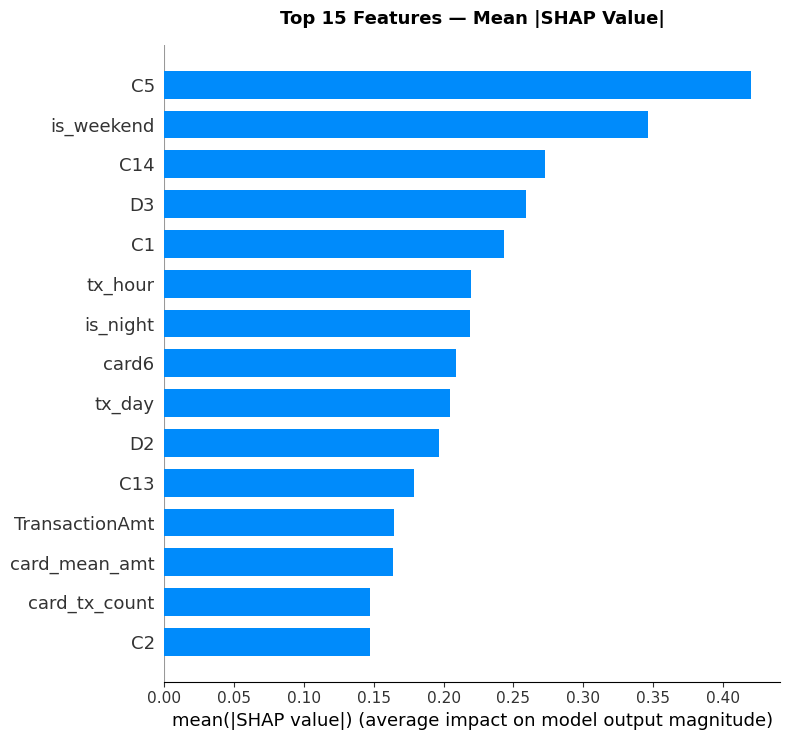

In [28]:
print("Calculating SHAP values...")
print("(Sampling 2,000 test transactions for speed)")
# Define feature_cols from loaded dataframe
feature_cols = [c for c in df.columns if c != 'isFraud']

# Sample for speed
sample_idx = np.random.RandomState(42).choice(
    len(X_test), 2000, replace=False)
X_test_sample = X_test.iloc[sample_idx]

# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

# Feature importance
mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': mean_shap
}).sort_values('mean_abs_shap', ascending=False)

print(f"\nTop 15 Features by SHAP Importance:")
print("-" * 45)
print(shap_importance.head(15).to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Top 15 Features — Mean |SHAP Value|',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/shap_fraud_importance.png',
            dpi=300, bbox_inches='tight')
plt.show()

**SHAP Finding - Fraud Detection Model**  
Top predictors: *C5 (count feature), is_weekend, C14, D3, C1  *  
Surprising: *time features (is_weekend, tx_hour, is_night) rank higher than transaction amount or card type*.  
Velocity features (*card_tx_count, card_mean_amt*) contribute 
but are secondary to anonymised count patterns.  
Insight: fraud is more behavioural and temporal than 
transactional - consistent with CNP fraud operating in digital patterns invisible to simple rule-based systems.